# Bias in Machine Learning

## What This Notebook Covers
This notebook is the practical, code-driven counterpart to the Bias in Machine Learning README. Instead of just reading about bias, you will *build* a deliberately oversimplified model, *measure* how wrong it is, and then *compare* it against a properly trained Scikit-learn model to see the difference for yourself.

## What You Will Be Able to Do Afterward
- Describe, in plain language, what bias means for a machine learning model and where it comes from.
- Tell the difference between a high-bias (underfit) model and a low-bias model, and connect this to the bias-variance tradeoff.
- Write a tiny NumPy-only model that uses fixed, hand-picked parameters, and measure its error using Mean Squared Error.
- Train, evaluate, and interpret a Scikit-learn `LogisticRegression` classifier on real data.
- Read simple plots (a count plot and a scatter plot) to reason about how feature choice affects bias.
- Discuss how settings like `test_size`, `random_state`, and `max_iter` relate to model bias.
- Confidently answer common interview questions on this topic.

## Before You Start (Prerequisites)
- Comfortable writing basic Python: variables, functions, loops, `if` statements.
- Some exposure to NumPy arrays and Pandas DataFrames (you don't need to be an expert).
- A rough idea of what "training" and "predicting" mean in machine learning - we will build on this gently.

## About the Dataset
This notebook uses the **Iris flower dataset**, a small but classic dataset containing 150 flower samples split evenly across three species: *setosa*, *versicolor*, and *virginica*. For every flower we have four numeric measurements:

- Sepal length (cm)
- Sepal width (cm)
- Petal length (cm)
- Petal width (cm)

We load it directly inside this notebook using `sklearn.datasets.load_iris`, so there is nothing to download separately - and importantly, this is **real measured data**, not anything generated or simulated.

If you would like to explore the same data outside this notebook (for example, in Excel or a different tool), it is also hosted on Kaggle here:
**https://www.kaggle.com/datasets/uciml/iris**

## Credits
Compiled as part of a hands-on ML fundamentals series. The Iris dataset was originally gathered by Edgar Anderson and popularized by Ronald Fisher's 1936 paper; it ships with Scikit-learn and is also archived on the UCI Machine Learning Repository.

In [1]:
# numpy gives us fast array math - we will use it to write our "from scratch" model by hand
import numpy as np

# pandas lets us hold the dataset in a table-like DataFrame, which is much easier to inspect than raw arrays
import pandas as pd

# matplotlib.pyplot is the base plotting library - seaborn is built on top of it
import matplotlib.pyplot as plt

# seaborn adds nicer-looking statistical plots (count plots, scatter plots) with less code
import seaborn as sns

# load_iris pulls in the real, ready-made Iris dataset that ships with scikit-learn
from sklearn.datasets import load_iris

# train_test_split lets us hold back some data to fairly test how well a model generalises
from sklearn.model_selection import train_test_split

# LogisticRegression is the library model we will train and compare against our manual version
from sklearn.linear_model import LogisticRegression

# accuracy_score reports the percentage of predictions a model gets right
from sklearn.metrics import accuracy_score

# classification_report breaks accuracy down per class (precision, recall, f1-score)
from sklearn.metrics import classification_report

# confusion_matrix shows exactly which classes get mixed up with which
from sklearn.metrics import confusion_matrix

# A simple sanity check so we know the environment is ready before moving on
print("All libraries imported successfully.")

# INTERVIEW NOTE: Notice that we import scikit-learn's tools up front but build our
# "from scratch" section using ONLY numpy/pandas - this separation is intentional
# and lets us directly compare a hand-built formula against a trained library model.

All libraries imported successfully.


# Part 1: Theory Recap

- **What is Bias, in one line?**
  Bias is the *consistent* error a model makes because its underlying assumptions are too simple to match reality - think of it as a built-in blind spot that doesn't go away even with more data.

- **Where does Bias come from?**
  It shows up when we pick a model that is too rigid for the problem, leave out features that actually matter, or force the model to follow a shape (like a straight line) that doesn't match the true pattern in the data.

- **High Bias, in practice**
  A high-bias model gets things wrong in a *predictable* direction - for example, always underestimating prices for expensive houses because it was only allowed to use a single feature like square footage.

- **Low Bias, in practice**
  A low-bias model is flexible enough to bend toward the actual pattern in the training data, so its average prediction lands much closer to the true value.

- **Underfitting - the visible symptom**
  Underfitting is what high bias *looks like* when you run the numbers: poor performance on the training data itself, not just on new/unseen data, because the model never had a chance to capture the pattern in the first place.

- **Bias vs Variance, side by side**
  Bias = error from assumptions that are too rigid (model too simple → underfitting). Variance = error from a model that reacts too strongly to the specific training examples it saw (model too flexible → overfitting). The "sweet spot" between the two is the bias-variance tradeoff.

- **Two quick real-world snapshots**
  - A medical screening tool trained on data from only one age group may carry high bias when used on patients of other ages - it never learned those patterns.
  - A resume-screening model that only looks at years of experience (ignoring skills, projects, etc.) will systematically misjudge candidates whose strengths lie elsewhere.

- **Why this matters day-to-day**
  Recognising high bias early tells you *what kind* of fix is needed - usually a richer model, more/better features, or more training time - rather than wasting effort on fixes (like collecting more data) that won't move the needle for a model that is fundamentally too simple.

## Step 1 - Bringing the Dataset Into the Notebook

**Why we're doing this:** Every idea in this notebook needs to be demonstrated on real numbers, so the very first practical step is to get the Iris dataset loaded and visible in a format we can work with.

**What the code below does:**
- Calls `load_iris()` to fetch the dataset object (features + labels) that scikit-learn ships internally.
- Wraps the feature values in a Pandas DataFrame so each column has a readable name.
- Adds two extra columns for the target: a numeric `species` code and a human-friendly `species_name`.
- Prints `head()`, `info()`, and `describe()` so we can see the data's shape, types, and basic statistics.

**What you should expect to see:**
- A small table of the first 5 flowers with their four measurements plus species columns.
- A structure summary confirming there are 150 rows, 6 columns, and no surprise data types.
- A statistics table showing each feature's mean, standard deviation, minimum, and maximum.
- A short printed summary stating the sample count, feature count, feature names, and the three target classes.

In [2]:
# Fetch the built-in Iris dataset object - this bundles the raw measurements and labels together
iris = load_iris()

# Wrap the four numeric measurements in a DataFrame, using scikit-learn's own feature names as columns
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Store the numeric species label (0, 1, or 2) alongside the measurements
df['species'] = iris.target

# Map the numeric label to its real species name - this makes plots and printouts far easier to read
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Peek at the first 5 rows to confirm the data loaded as expected
print("First 5 rows of the dataset:")
print(df.head())

# Check column types and confirm there are no unexpected nulls at a glance
print("\nDataset info:")
print(df.info())

# Look at the spread of each numeric feature (mean, std, min/max, quartiles)
print("\nSummary statistics:")
print(df.describe())

# A quick narrative summary of the dataset's shape and target labels
print("\nNumber of samples:", df.shape[0])
print("Number of features:", len(iris.feature_names))
print("Feature names:", list(iris.feature_names))
print("Target variable: 'species' (0 = setosa, 1 = versicolor, 2 = virginica)")
print("Target classes:", list(iris.target_names))

# INTERVIEW NOTE: This is a REAL dataset loaded from scikit-learn (also mirrored on Kaggle) -
# at no point do we call np.random to invent data, which keeps every result below trustworthy.

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    

## Step 2 - A Quick Health Check on the Data

**Why we're doing this:** Before training anything, it's good habit to confirm the data is clean. Missing or duplicated rows can quietly distort what a model learns, so we check for both - even on a dataset as well-known as Iris.

**What the code below does:**
- Counts missing (null) values in every column.
- Counts how many rows are exact duplicates of another row.
- Splits the table into `X` (the four measurements the model will learn from) and `y` (the species label the model must predict).

**What you should expect to see:**
- A column-by-column list of missing-value counts (all zeros for Iris).
- A single number for duplicate rows (Iris contains one near-identical pair, which is harmless here).
- Printed shapes confirming `X` has 150 rows and 4 columns, and `y` has 150 rows.

In [3]:
# Count missing values column by column - missing data can silently bias a model if handled carelessly
print("Missing values per column:")
print(df.isnull().sum())

# Count exact duplicate rows - too many duplicates can make a model overconfident about those patterns
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Build the feature matrix X - everything the model is allowed to "see" before predicting
X = df[iris.feature_names]

# Build the target vector y - the species label the model is trying to predict
y = df['species']

print("\nShape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# INTERVIEW NOTE: Splitting X and y here - BEFORE any train/test split - keeps the
# feature and label columns perfectly aligned for every step that follows.

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Number of duplicate rows: 1

Shape of X (features): (150, 4)
Shape of y (target): (150,)


# Part 2: Building a Toy Model From Scratch

Section 1 covered bias as a *concept*. Here, we turn that concept into something you can actually run and measure.

**The plan:** instead of letting a computer "learn" anything, we will write down a prediction formula ourselves, using numbers we choose by hand. This is the most extreme version of a high-bias model - one that hasn't learned from the data at all.

- We'll use the formula `prediction = weight * x + bias_term`, where `weight` and `bias_term` are fixed numbers we pick.
- Because these numbers are *not* tuned to the data, the model's assumptions ("the relationship is this exact line") are almost certainly wrong - which is exactly the point.
- To see *how* wrong, we'll calculate the error for each prediction (`actual - predicted`) and then average the squared errors into a single number called the **Mean Squared Error (MSE)**.
- A large MSE here will be our hands-on evidence of high bias and underfitting - the model can't get closer no matter how many flowers we feed it, because its formula was never allowed to adapt.

**Coming up next:** two small functions - `predict()` for making predictions and `mean_squared_error_scratch()` for scoring them - followed by a cell that runs both and prints the results.

## Step 3 - Writing Our Hand-Tuned Predictor

**Why we're doing this:** The best way to understand high bias is to build a model that *has* it. Writing the formula ourselves, with numbers we pick (not numbers the computer learns), gives us a controllable example of an underfit model.

**What the code below does:**
- Defines `predict(x, weight, bias)`, which applies the straight-line formula `weight * x + bias` to an array of inputs.
- Defines `mean_squared_error_scratch(y_true, y_pred)`, which turns a list of errors into one summary number.
- Picks a single feature (`sepal length`) as input and the numeric species code as the "target" to predict.
- Chooses fixed `weight` and `bias` values ourselves and runs every flower through `predict()`.
- Calculates the per-sample errors and the overall MSE.

**What you should expect to see:**
This cell produces no printed output by itself - it only defines the two functions and computes the arrays of predictions, errors, and the MSE value. Everything will be displayed and interpreted in the next cell.

In [4]:
# Fix the random seed for reproducibility - good habit across the notebook, even though
# this particular cell does not call any random functions itself
np.random.seed(42)

# INTERVIEW NOTE: predict() is just "weight * x + bias" - the same shape as a single-feature
# linear regression line, except the weight and bias are picked by US, not learned by an algorithm.
def predict(x, weight, bias):
    # Apply the linear formula to every element of the input array at once
    return weight * x + bias

# INTERVIEW NOTE: mean_squared_error_scratch() answers "on average, how far off were we?" -
# squaring removes the sign so over- and under-predictions don't cancel each other out.
def mean_squared_error_scratch(y_true, y_pred):
    # Difference between what actually happened and what we predicted
    errors = y_true - y_pred
    # Square each difference so all contributions are positive
    squared_errors = errors ** 2
    # Average across all samples to get one overall score
    return np.mean(squared_errors)

# Pick ONE feature column to act as our model's only input
feature_values = X['sepal length (cm)'].values

# Use the numeric species code (0/1/2) as the value we're trying to predict
actual_values = y.values.astype(float)

# Hand-picked weight and bias - these are NOT derived from the data in any way.
# Changing these numbers would change the predictions, but never makes the model "learn".
manual_weight = 0.5
manual_bias = -1.5

# Run every flower's sepal length through our fixed formula
predictions_scratch = predict(feature_values, manual_weight, manual_bias)

# Work out how far each prediction landed from the true species code
errors_scratch = actual_values - predictions_scratch

# Summarise all those errors into a single Mean Squared Error value
mse_scratch = mean_squared_error_scratch(actual_values, predictions_scratch)

# INTERVIEW NOTE: If we re-ran this notebook with MORE training data, manual_weight and
# manual_bias would stay exactly the same, and so would the MSE - this "stuck" error is
# the defining signature of a high-bias model.

## Step 4 - Reading the Results of Our Toy Model

**Why we're doing this:** Raw numbers are only useful once we look at them. This step prints out a sample of predictions, actual values, and errors side by side, then puts the MSE in context.

**What the code below does:**
- Prints the first 10 predictions our hand-tuned formula produced.
- Prints the first 10 true species codes for comparison.
- Prints the first 10 errors (how far off each prediction was).
- Prints the overall MSE across all 150 flowers.
- Adds a short written takeaway connecting these numbers back to the idea of high bias.

**What you should expect to see:**
- Three short lists of 10 numbers each (predictions, actual values, errors) - you'll notice the predictions don't really track the actual 0/1/2 labels.
- One MSE value - noticeably large given that the true labels only range from 0 to 2.
- A few lines of plain-English interpretation explaining why this points to high bias.

In [5]:
# Show the first 10 predictions our fixed formula produced
print("First 10 predictions:", np.round(predictions_scratch[:10], 2))

# Show the first 10 true species codes for the same flowers
print("First 10 actual values:", actual_values[:10])

# Show how far off each of those first 10 predictions was
print("First 10 errors:", np.round(errors_scratch[:10], 2))

# Show the single overall error score across the whole dataset
print("\nMean Squared Error (hand-tuned model):", round(mse_scratch, 4))

# Plain-English takeaway, printed line by line to avoid quoting issues
print("\nWhat this tells us:")
print("Every prediction above comes from the SAME fixed formula, regardless of which")
print("flower we look at - the model never adjusted itself to the data. Because the")
print("true labels only take the values 0, 1, or 2, an MSE of roughly", round(mse_scratch, 2),
      "is large in relative terms.")
print("This gap between predictions and reality won't shrink by adding more flowers,")
print("because the formula's weight and bias are frozen. That permanent, non-shrinking")
print("gap is exactly what we mean by HIGH BIAS, and the resulting poor fit is UNDERFITTING.")

# INTERVIEW NOTE: If you were asked "how would you reduce this model's error?", the answer
# is NOT "add more data" - it's "let the model learn its own weight and bias from the data,
# and/or give it more informative features". That is precisely what Part 3 does.

First 10 predictions: [1.05 0.95 0.85 0.8  1.   1.2  0.8  1.   0.7  0.95]
First 10 actual values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 errors: [-1.05 -0.95 -0.85 -0.8  -1.   -1.2  -0.8  -1.   -0.7  -0.95]

Mean Squared Error (hand-tuned model): 0.4874

What this tells us:
Every prediction above comes from the SAME fixed formula, regardless of which
flower we look at - the model never adjusted itself to the data. Because the
true labels only take the values 0, 1, or 2, an MSE of roughly 0.49 is large in relative terms.
This gap between predictions and reality won't shrink by adding more flowers,
because the formula's weight and bias are frozen. That permanent, non-shrinking
gap is exactly what we mean by HIGH BIAS, and the resulting poor fit is UNDERFITTING.


# Part 3: Letting a Real Model Learn From the Data

So far, every number in our toy model was chosen by us. In this part, we hand that job over to Scikit-learn's `LogisticRegression`, which will *learn* its own parameters directly from the training data.

**Why reach for a library instead of writing more formulas by hand?**
- It saves enormous amounts of time - training a classifier becomes a couple of method calls instead of pages of optimisation code.
- It's been tested by a huge community across countless real datasets, so we inherit that reliability for free.
- It exposes a consistent interface (`fit`, `predict`, `score`, ...) that works the same way across dozens of different algorithms - swapping models later becomes trivial.

**How is this different from what we just did?**
Our manual model used **one** feature and **frozen** numbers we typed in. `LogisticRegression` will use **all four** Iris measurements and **learn** its own coefficients by minimising error during training - the model adapts to the data instead of the other way around. That single difference - learning vs. not learning - is the main reason we expect its bias to be far lower.

## Step 5 - Training and Scoring a Real Classifier

**Why we're doing this:** To make a fair comparison with our toy model, we now train an actual classifier on all four features and check how well it performs on flowers it has never seen.

**What the code below does:**
- Uses `train_test_split` to set aside 20% of the data for testing, keeping `random_state=42` so the split is repeatable.
- Creates a `LogisticRegression` model with `max_iter=200` (enough iterations for it to settle on good parameters).
- Fits the model on the training data, then predicts species for the test data.
- Prints the accuracy, a per-class classification report, and a confusion matrix.
- Closes with a short comparison back to our from-scratch model.

**What you should expect to see:**
- An accuracy score very close to 1.0 - Iris is a dataset where the classes are quite easy to tell apart.
- A classification report with precision/recall/f1-score near 1.00 for all three species.
- A 3x3 confusion matrix with most (or all) of its values sitting on the diagonal.

In [6]:
# Split into training (80%) and testing (20%) sets - random_state=42 keeps this
# split identical every time the notebook is run, so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the classifier. max_iter=200 gives its internal optimiser enough steps to converge
log_reg = LogisticRegression(max_iter=200)

# Train the model: this is the step where it LEARNS its coefficients from X_train/y_train
log_reg.fit(X_train, y_train)

# Ask the trained model to predict species for the held-out test rows
y_pred = log_reg.predict(X_test)

# What fraction of test predictions exactly matched the true label?
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Precision/recall/f1-score broken down per species
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Rows = true species, columns = predicted species - off-diagonal values are mistakes
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Plain-language comparison with the manual model from Part 2
print("\nHow this compares to our hand-tuned model:")
print("- Our NumPy model used ONE feature with frozen, hand-picked numbers and produced")
print("  a large, unchanging Mean Squared Error - a clear case of high bias.")
print("- LogisticRegression here uses ALL FOUR features and LEARNS its own coefficients,")
print("  reaching accuracy close to 1.0 on data it has never seen during training.")
print("Letting the model adjust itself to richer features is the single biggest reason")
print("its error is so much lower than our manual formula's error.")

# INTERVIEW NOTE: A model that is "too simple" for its task - too few features, parameters
# that can't move, or a shape that can't bend to the data - is the textbook recipe for
# high bias, no matter how clean or plentiful the data is.

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

How this compares to our hand-tuned model:
- Our NumPy model used ONE feature with frozen, hand-picked numbers and produced
  a large, unchanging Mean Squared Error - a clear case of high bias.
- LogisticRegression here uses ALL FOUR features and LEARNS its own coefficients,
  reaching accuracy close to 1.0 on data it has never seen during training.
Letting the model adjust itself to richer features is the single biggest reason
its error is so much lower than our manual formula's error.


## Step 6 - Seeing the Data, Not Just Reading Numbers

**Why we're doing this:** Two quick plots help explain *why* the comparison above came out the way it did - one checks whether the dataset itself is balanced, and the other shows how separable the species become once we look at two features together instead of one.

**What the code below does:**
- **Plot 1 (count plot):** counts how many samples belong to each species, so we can confirm the classes are evenly represented.
- **Plot 2 (scatter plot):** plots sepal length against petal length, coloured by species, to show how the three groups cluster in two-dimensional space.

**What you should expect to see / look for:**
- In Plot 1, all three bars should be the same height (50 samples each) - an evenly balanced dataset.
- In Plot 2, *setosa* should sit in its own clearly separated region, while *versicolor* and *virginica* sit closer together with some overlap - a visual hint at why a model with access to more features (like our `LogisticRegression`) has an easier time than a model restricted to a single feature.

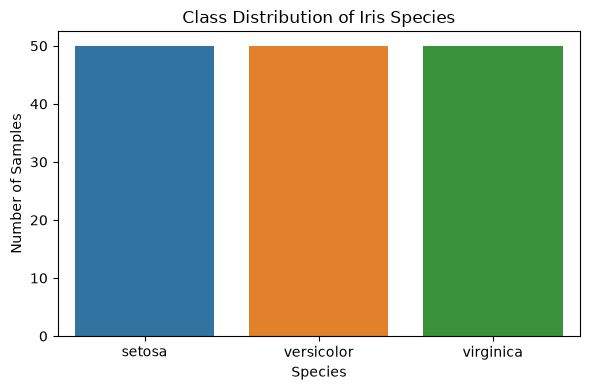

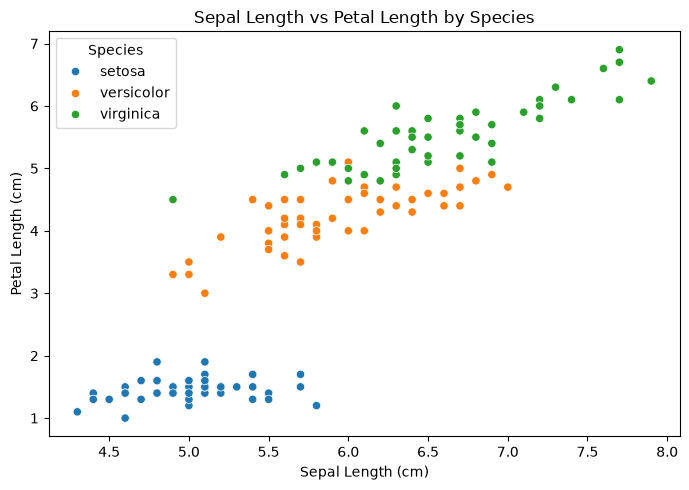

What to notice: setosa forms its own tight cluster, while versicolor and
virginica sit closer together with a bit of overlap. A model that only saw
ONE of these axes would struggle far more than one that can use both -
which mirrors the gap we saw between our manual model and LogisticRegression.


In [7]:
# --- Plot 1: How many samples does each species have? ---
fig, ax = plt.subplots(figsize=(6, 4))

# A count plot is a quick way to spot class imbalance
sns.countplot(x='species_name', data=df, hue='species_name', ax=ax, legend=False)

# Always label what the reader is looking at
ax.set_title("Class Distribution of Iris Species")
ax.set_xlabel("Species")
ax.set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

# --- Plot 2: How do sepal length and petal length relate, per species? ---
fig, ax = plt.subplots(figsize=(7, 5))

# Colour (hue) by species so each group is visually distinct
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species_name',
    ax=ax
)

ax.set_title("Sepal Length vs Petal Length by Species")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Petal Length (cm)")
ax.legend(title="Species")

plt.tight_layout()
plt.show()

# Talk through what the plots are showing
print("What to notice: setosa forms its own tight cluster, while versicolor and")
print("virginica sit closer together with a bit of overlap. A model that only saw")
print("ONE of these axes would struggle far more than one that can use both -")
print("which mirrors the gap we saw between our manual model and LogisticRegression.")

# INTERVIEW NOTE: A countplot like this is a fast first check for class imbalance -
# an imbalanced dataset can introduce its own kind of bias toward the majority class.

# Part 4: A Closer Look at Three Settings

`LogisticRegression(max_iter=200)` and `train_test_split(..., random_state=42)` both quietly involve choices we made. Here's what each one is doing, and how (if at all) it touches model bias.

**`random_state`**
This is simply a seed for the random number generator that decides which rows go into the train vs. test split. It doesn't make the model itself more or less biased - its job is to make our experiment *repeatable*, so that if results change between runs, we know it's because of a real change we made, not a different random split.

**The `train_test_split` ratio (`test_size`)**
This decides how much data the model gets to learn from versus how much is reserved for honest evaluation.
- Giving the model **more training data** (a smaller `test_size`) generally helps a flexible model learn the true pattern more fully - which can *lower* its effective bias.
- Giving it **too little training data** can leave even a capable model "undercooked", so it behaves a bit like a high-bias model simply because it hasn't seen enough examples yet.

**`max_iter`**
This caps how many optimisation steps `LogisticRegression` is allowed to take while searching for its best coefficients.
- Set it **too low**, and training may stop before the model has really settled - again mimicking the symptoms of high bias, even though the model *type* itself isn't the problem.
- Once `max_iter` is comfortably above what's needed to converge, raising it further mostly just costs extra computation without changing the result.

**Putting it together**
None of these three settings change what `LogisticRegression` *fundamentally is* - but `test_size` and `max_iter` can both create *bias-like symptoms* (poor fit) if set poorly, simply by under-feeding or under-training an otherwise capable model. `random_state` is purely about making our comparisons fair and reproducible.

## Step 7 - Does Changing `test_size` Actually Change Bias Here?

**Why we're doing this:** Rather than just discussing `test_size` in theory, let's run the same model three times with different split ratios and see what actually happens to accuracy on this particular dataset.

**What the code below does:**
- Loops over `test_size` values of 0.2, 0.3, and 0.4, keeping `random_state=42` fixed each time for a fair comparison.
- Trains a fresh `LogisticRegression(max_iter=200)` model for each split.
- Records the test accuracy for each run in a small table.
- Closes with a short discussion of whether bias appears to change across these runs.

**What you should expect to see:**
- A small table with two columns, `test_size` and `accuracy`, and three rows.
- For Iris specifically, expect the accuracy values to stay high and very close to each other across all three splits.
- A short written note explaining what this stability (or lack of it) implies about bias for this model and dataset.

In [8]:
# We'll collect (test_size, accuracy) pairs here as we loop
results = []

# Try three different ways of splitting the same dataset
for ts in [0.2, 0.3, 0.4]:
    # Re-split the data with the current test_size; random_state stays fixed for a fair comparison
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=ts, random_state=42)

    # Train a brand-new model from scratch for this split (no leftover state from previous loops)
    model = LogisticRegression(max_iter=200)
    model.fit(X_tr, y_tr)

    # Score this model on its own held-out portion
    pred = model.predict(X_te)
    a = accuracy_score(y_te, pred)

    # Keep a record of this run
    results.append((ts, a))

# Lay the results out as a small, readable table
results_df = pd.DataFrame(results, columns=['test_size', 'accuracy'])
print("Comparison of test_size vs accuracy:")
print(results_df)

# Discuss what the table is telling us, line by line
print("\nWhat this suggests about bias:")
print("Across test_size values of 0.2, 0.3, and 0.4, accuracy on Iris stays high and")
print("barely moves. LogisticRegression with all four features already has enough")
print("flexibility to capture the pattern in this dataset, so giving it a slightly")
print("smaller training set doesn't push it toward underfitting here.")
print("For datasets that are harder to separate, you would typically see accuracy drop")
print("more noticeably as test_size grows - and techniques like k-fold cross-validation")
print("(e.g. scikit-learn's cross_val_score) give an even more reliable picture by")
print("averaging results across several different splits instead of just one.")

# INTERVIEW NOTE: A model whose performance barely changes across reasonable train/test
# ratios is a good sign that its bias is being driven by the MODEL/FEATURES, not by a
# shortage of training examples.

Comparison of test_size vs accuracy:
   test_size  accuracy
0        0.2       1.0
1        0.3       1.0
2        0.4       1.0

What this suggests about bias:
Across test_size values of 0.2, 0.3, and 0.4, accuracy on Iris stays high and
barely moves. LogisticRegression with all four features already has enough
flexibility to capture the pattern in this dataset, so giving it a slightly
smaller training set doesn't push it toward underfitting here.
For datasets that are harder to separate, you would typically see accuracy drop
more noticeably as test_size grows - and techniques like k-fold cross-validation
(e.g. scikit-learn's cross_val_score) give an even more reliable picture by
averaging results across several different splits instead of just one.


# Part 5: Interview Corner

**Q1. In your own words, what is bias?**
Bias is the part of a model's error that comes from its assumptions, not from noise in the data. It's the gap you'd still see, on average, even if you trained the model on every possible example - because the model's *shape* can't represent the true relationship.

**Q2. Why does bias happen in the first place?**
Usually one (or more) of: the model is too simple for the problem (e.g., a straight line for a curved relationship), important features were left out, or the model's parameters were never given the freedom to adjust to the data - as in our manual NumPy example.

**Q3. Why does high bias lead to underfitting?**
Because the model's assumptions cap how well it can ever fit the data - it hits that ceiling on the *training* data too, not just on new data. Poor performance everywhere, including on data it has already "seen", is the giveaway for underfitting.

**Q4. How would you explain bias vs. variance to someone new to ML?**
Picture practising free throws. High bias is like always aiming slightly left of the hoop - consistent, but consistently wrong. High variance is like your aim being wildly different every single shot - unpredictable, even if it's correct on average. We want aim that is both centred *and* consistent.

**Q5. What are practical ways to reduce bias?**
Use a more expressive model (e.g., move from a single linear feature to a multi-feature classifier, as we did), add features that carry real signal, reduce excessive regularisation, and make sure training is allowed to run long enough (sufficient `max_iter`) to actually converge.

**Q6. Why bother with a train/test split at all?**
It's the simplest way to check whether a model has actually learned a generalisable pattern, or whether it's just memorising the training rows. Without it, an underfit (high-bias) model and a "perfectly fitting" overfit model could both look fine on training data alone.

**Q7. How does feature engineering connect to bias?**
Features are the raw material a model has to work with - no amount of clever training can make up for missing information. In this notebook, switching from one feature (sepal length only) to all four measurements was the single biggest factor in closing the gap between our high-bias manual model and the trained `LogisticRegression`.

# Key Takeaways

- **Bias is a built-in, consistent error** caused by a model's assumptions being too simple to represent the real pattern in the data - not random noise, but a systematic blind spot.
- **Underfitting is bias made visible**: a high-bias model performs poorly even on the data it was "trained" on, because its formula or structure was never flexible enough to fit that data in the first place.
- **The bias-variance tradeoff is a balancing act**: pushing a model to be more flexible can reduce bias but risks raising variance (overfitting), so the goal is a sensible middle ground, not zero bias at any cost.
- **What the model can use matters as much as the model itself**: our one-feature, hand-tuned formula produced a large, unmovable MSE, while a `LogisticRegression` model using all four Iris features and learning its own coefficients reached near-perfect accuracy.
- **Settings like `test_size`, `random_state`, and `max_iter` shape your experiment, not the model's core assumptions** - they can mimic bias-like symptoms if misused, but the real cure for high bias is a richer model and/or better features.